<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment12/DNN_Assignment_12_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torchmetrics
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 45.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import os
import random
import torch
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy
import torch.optim as optim
from tqdm import tqdm
import time
from torchinfo import summary


In [3]:
# Load dataset
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
val_ratio = 0.1
generator = torch.Generator().manual_seed(seed)
use_reduced_data = True

transform = transforms.Compose([
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-30, 30)),
    # transforms.ColorJitter(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformTest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR10Dataset = torchvision.datasets.CIFAR10(root='.', download=True)
full_train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transformTest)

if use_reduced_data:
    total_reduced_size = 10000
    selected_indices = torch.randperm(len(full_train_dataset), generator=generator)[:total_reduced_size]
else:
    selected_indices = torch.arange(len(full_train_dataset))

val_size = int(len(selected_indices) * val_ratio)
train_size = len(selected_indices) - val_size
train_indices, val_indices = random_split(selected_indices, [train_size, val_size], generator=generator)


train_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transform),
    train_indices.indices
)

val_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transformTest),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


In [4]:
# import torch.nn as nn
# from torchvision.models import resnet50, mobilenet_v3_large

# def get_resnet50(num_classes=10):
#     model = resnet50(pretrained=True)

#     # Adjust first conv and maxpool for CIFAR-10 input size
#     model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
#     model.maxpool = nn.Identity()

#     # Freeze all layers initially
#     for param in model.parameters():
#         param.requires_grad = False

#     # Unfreeze last half: layer3, layer4, and fc
#     for name, param in model.named_parameters():
#         if "layer3" in name or "layer4" in name or "fc" in name:
#             param.requires_grad = True

#     # Replace final classification layer
#     model.fc = nn.Linear(model.fc.in_features, num_classes)
#     return model

# def get_mobilenetv3(num_classes=10):
#     model = mobilenet_v3_large(pretrained=True)

#     # Adjust first conv stride for 32x32 input
#     model.features[0][0].stride = (1, 1)

#     # Freeze all layers initially
#     for param in model.parameters():
#         param.requires_grad = False

#     # Unfreeze last half of features (features[8:] since total 17 blocks) + classifier
#     for i in range(8, len(model.features)):
#         for param in model.features[i].parameters():
#             param.requires_grad = True

#     for param in model.classifier.parameters():
#         param.requires_grad = True

#     # Replace final classification layer
#     in_features = model.classifier[-1].in_features
#     model.classifier[-1] = nn.Linear(in_features, num_classes)
#     return model

In [5]:
import torch.nn as nn
from torchvision.models import resnet50, resnet101

def get_resnet50(num_classes=10):
    model = resnet50(pretrained=True)

    # Adjust first conv and maxpool for CIFAR-10 input size
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last half: layer3, layer4, and fc
    for name, param in model.named_parameters():
        if "layer3" in name or "layer4" in name or "fc" in name:
            param.requires_grad = True

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet101(num_classes=10):
    model = resnet101(pretrained=True)

    # Adjust first conv and maxpool for CIFAR-10 input size
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last half: layer3, layer4, and fc
    for name, param in model.named_parameters():
        if "layer3" in name or "layer4" in name or "fc" in name:
            param.requires_grad = True

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [6]:

resnet50_model = get_resnet50()
summary(resnet50_model, (1, 3, 32, 32))


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           (1,728)
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           (128)
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─Identity: 1-4                          [1, 64, 32, 32]           --
├─Sequential: 1-5                        [1, 256, 32, 32]          --
│    └─Bottleneck: 2-1                   [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 32, 32]    

In [7]:
resnet101_model = get_resnet101()
summary(resnet101_model, (1, 3, 32, 32))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 185MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           (1,728)
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           (128)
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─Identity: 1-4                          [1, 64, 32, 32]           --
├─Sequential: 1-5                        [1, 256, 32, 32]          --
│    └─Bottleneck: 2-1                   [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 32, 32]    

In [8]:

def train(model, train_loader, val_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)
    results = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = validation(model, val_loader, device, show_metrics=False)
        scheduler.step()
        # print(f'Learning Rate: {scheduler.get_last_lr()[-1]:0.4e}')
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s)  - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

def validation(model, test_loader, device, show_metrics=True):
    metric = MulticlassAccuracy(num_classes=10).to(device)
    model.eval()
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            metric.update(outputs, labels)
            total_loss += loss.item()

    accuracy_val = metric.compute().item()
    avg_loss = total_loss / len(test_loader)

    if show_metrics:
        print(f"Validation Accuracy: {accuracy_val:.4f} Loss: {avg_loss:.4f}")
    return accuracy_val, avg_loss



In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 25
learning_rate = 1e-3
resnet50_model.to(device)
history_resnet50 = train(resnet50_model, train_loader, val_loader, epochs, learning_rate, device)
validation(resnet50_model, test_loader, device)

Epoch 1/25(19.57s)  - accuracy: 0.3830  - loss: 1.8477  - val_accuracy: 0.4653  - val_loss: 1.6919
Epoch 2/25(18.70s)  - accuracy: 0.5154  - loss: 1.5776  - val_accuracy: 0.5921  - val_loss: 1.4273
Epoch 3/25(18.90s)  - accuracy: 0.5670  - loss: 1.4693  - val_accuracy: 0.6769  - val_loss: 1.2561
Epoch 4/25(18.94s)  - accuracy: 0.5947  - loss: 1.4062  - val_accuracy: 0.6507  - val_loss: 1.3117
Epoch 5/25(19.51s)  - accuracy: 0.6322  - loss: 1.3331  - val_accuracy: 0.7140  - val_loss: 1.1500
Epoch 6/25(19.56s)  - accuracy: 0.6499  - loss: 1.3007  - val_accuracy: 0.7042  - val_loss: 1.2158
Epoch 7/25(19.76s)  - accuracy: 0.6657  - loss: 1.2521  - val_accuracy: 0.7477  - val_loss: 1.1071
Epoch 8/25(19.41s)  - accuracy: 0.6859  - loss: 1.2171  - val_accuracy: 0.7391  - val_loss: 1.1186
Epoch 9/25(19.54s)  - accuracy: 0.7070  - loss: 1.1696  - val_accuracy: 0.7407  - val_loss: 1.0862
Epoch 10/25(19.46s)  - accuracy: 0.7207  - loss: 1.1449  - val_accuracy: 0.7891  - val_loss: 0.9922
Epoch 11/

(0.8309999704360962, 0.9078267858286572)

In [10]:

resnet101_model.to(device)
history_resnet101 = train(resnet101_model, train_loader, val_loader, epochs, learning_rate, device)
validation(resnet101_model, test_loader, device)

Epoch 1/25(38.66s)  - accuracy: 0.3277  - loss: 1.9415  - val_accuracy: 0.4070  - val_loss: 1.9351
Epoch 2/25(38.61s)  - accuracy: 0.4529  - loss: 1.6784  - val_accuracy: 0.5706  - val_loss: 1.4756
Epoch 3/25(38.55s)  - accuracy: 0.5132  - loss: 1.5662  - val_accuracy: 0.6165  - val_loss: 1.3689
Epoch 4/25(38.59s)  - accuracy: 0.5532  - loss: 1.4881  - val_accuracy: 0.6152  - val_loss: 1.3983
Epoch 5/25(38.68s)  - accuracy: 0.5908  - loss: 1.4262  - val_accuracy: 0.6639  - val_loss: 1.2882
Epoch 6/25(38.79s)  - accuracy: 0.6104  - loss: 1.3790  - val_accuracy: 0.6783  - val_loss: 1.2375
Epoch 7/25(38.89s)  - accuracy: 0.6262  - loss: 1.3481  - val_accuracy: 0.7274  - val_loss: 1.1538
Epoch 8/25(38.64s)  - accuracy: 0.6491  - loss: 1.3015  - val_accuracy: 0.7056  - val_loss: 1.2025
Epoch 9/25(38.50s)  - accuracy: 0.6578  - loss: 1.2635  - val_accuracy: 0.7198  - val_loss: 1.1537
Epoch 10/25(38.52s)  - accuracy: 0.6756  - loss: 1.2291  - val_accuracy: 0.7089  - val_loss: 1.1678
Epoch 11/

(0.814300000667572, 0.9505024753558408)

In [11]:

import matplotlib.pyplot as plt
def plot_history(history, title):
    # Unpack the history
    train_acc = [row[0] for row in history]
    train_loss = [row[1] for row in history]
    val_acc   = [row[2] for row in history]
    val_loss  = [row[3] for row in history]
    epochs = range(1, len(history) + 1)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.suptitle(f'{title}', fontsize=16)
    plt.tight_layout()
    plt.show()


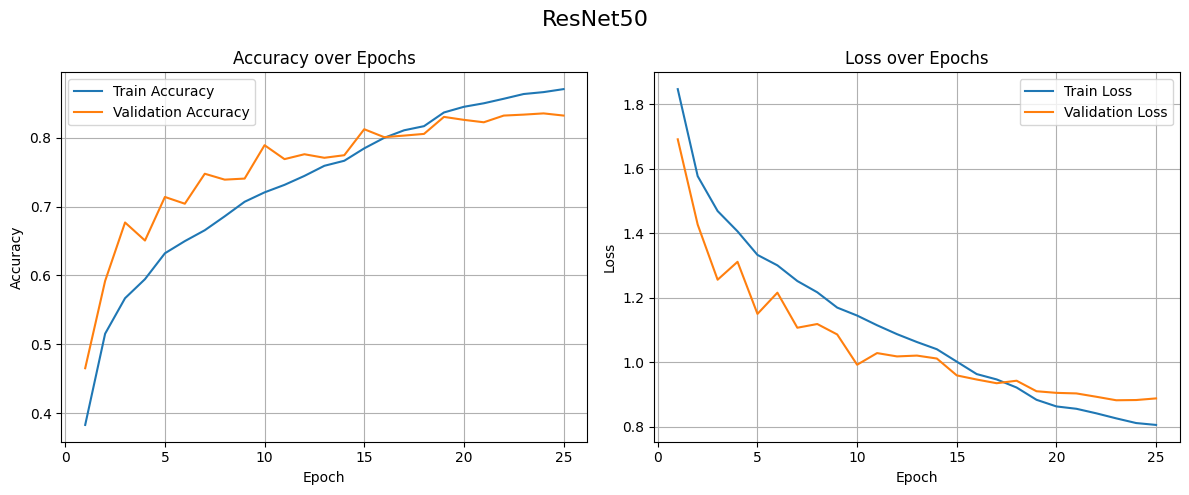

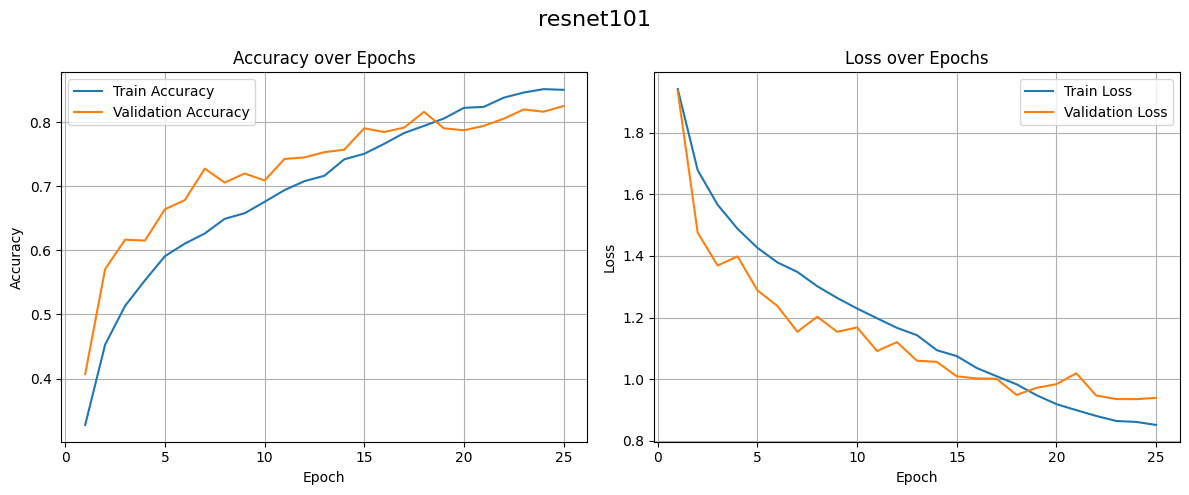

In [12]:

plot_history(history_resnet50, 'ResNet50')
plot_history(history_resnet101, 'resnet101')